In [120]:
print("Building makemore Part 5: Building a WaveNet")

Building makemore Part 5: Building a WaveNet


In [121]:
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [122]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [123]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [124]:
# shuffle up the words
import random
random.seed(42)
random.shuffle(words)

In [125]:
# build the dataset
block_size = 8 # context length: how many characters do we take to predict the next one?


def build_dataset(words):
    X, Y = [], []

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])      # 80%
Xdev, Ydev = build_dataset(words[n1:n2]) # 10%
Xte, Yte = build_dataset(words[n2:])     # 10%

torch.Size([182625, 8]) torch.Size([182625])
torch.Size([22655, 8]) torch.Size([22655])
torch.Size([22866, 8]) torch.Size([22866])


In [126]:
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '--->', itos[y.item()])

........ ---> y
.......y ---> u
......yu ---> h
.....yuh ---> e
....yuhe ---> n
...yuhen ---> g
..yuheng ---> .
........ ---> d
.......d ---> i
......di ---> o
.....dio ---> n
....dion ---> d
...diond ---> r
..diondr ---> e
.diondre ---> .
........ ---> x
.......x ---> a
......xa ---> v
.....xav ---> i
....xavi ---> e


In [127]:
# Near copy paste of the layers we have developed in Part 3

# -------------------------------------------------------------------------------

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5  # note: kaiming init
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

# -------------------------------------------------------------------------------

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)

        # buffers (trained with a running 'momentum update')
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training:
            if x.ndim == 2:
                dim = 0
            
            elif x.ndim == 3:
                dim = (0,1)

            xmean = x.mean(dim, keepdim=True)  # batch mean
            xvar = x.var(dim, keepdim=True)    # batch variance
        else:
            xmean = self.running_mean
            xvar = self.running_var

        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)  # normalize to unit variance
        self.out = self.gamma * xhat + self.beta

        # update the buffers
        if self.training:
            with torch.no_grad():
                self.running_mean = (
                    (1 - self.momentum) * self.running_mean
                    + self.momentum * xmean
                )
                self.running_var = (
                    (1 - self.momentum) * self.running_var
                    + self.momentum * xvar
                )

        return self.out

    def parameters(self):
        return [self.gamma, self.beta]


# --------------------------------------------------------------------

class Tanh:

    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

class Embedding:

    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn(num_embeddings, embedding_dim)

    def __call__(self, IX):
        self.out = self.weight[IX]
        return self.out

    def parameters(self):
        return [self.weight]

class flattenConsecutive:

    def __init__(self, n):
        self.n = n 

    def __call__(self, x):
        B,T,C  = x.shape
        x = x.view(B,(T//self.n), self.n*C)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out


    # this was my code that i wrote for the faltenconsecutive
    # def __call__(self, x):
    #     self.out = x.view(x.shape[0],(x.shape[1]//2), -1)
    #     return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self,layers):
        self.layers = layers

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out
    
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [128]:
torch.manual_seed(42); # seed rng for reproducibility

In [129]:
n_embd = 10    # the dimensionality of the character embedding vectors
n_hidden = 68 # the number of neurons in the hidden layer of the MLP

C = torch.randn((vocab_size, n_embd))
# now we have a notion of a model insted of layers , and model is a module (sequential module)
model  = Sequential([
    Embedding(vocab_size, n_embd),
    flattenConsecutive(2),Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    flattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
    flattenConsecutive(2),Linear(n_hidden * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),

    Linear(n_hidden, vocab_size),
])

# parameter init
with torch.no_grad():
    model.layers[-1].weight *= 0.1  # last layer make less confident

parameters = model.parameters()
#parameter we are going to simply write it as model.parameters
print(sum(p.nelement() for p in parameters))  # number of parameters in total

for p in parameters:
    p.requires_grad = True

22397


In [132]:
#fixing the bug in batchnorm1d layer
for layer in model.layers:
    print(layer.__class__.__name__, ":", tuple(layer.out.shape))

Embedding : (32, 8, 10)
flattenConsecutive : (32, 4, 20)
Linear : (32, 4, 68)
BatchNorm1d : (32, 4, 68)
Tanh : (32, 4, 68)
flattenConsecutive : (32, 2, 136)
Linear : (32, 2, 68)
BatchNorm1d : (32, 2, 68)
Tanh : (32, 2, 68)
flattenConsecutive : (32, 136)
Linear : (32, 68)
BatchNorm1d : (32, 68)
Tanh : (32, 68)
Linear : (32, 27)


In [ ]:
e = torch.randn(32,4,68)
emean = e.mean(0,keepdim= True) #1,4,68
evar = e.var(0,keepdim= True) #1,4,68
ehat = (e - emean)/torch.sqrt(evar + 1e-5) #32,4,68
ehat.shape
#so above we are receving an input 32,4,68 and then we are doing mean over the zeroth dimension and that gives us 1,4,68
#we are doing the mean over the first dimension onlyand same goes for variance, so it gives us the mean and variance that maintains [1,(4),68] the 1st dimesnion which here is (4)
#so looking at runing mean and variance

torch.Size([32, 4, 68])

In [ ]:
model.layers[3].running_mean.shape
#so this batch norm is corrently working in parallel over 4,68 insted of just 68 channels
#so here we are maintining the variance for each of the 4 bigrams indivudually but what we want is to just have one vector of variance for all of the bigrams 
#so insted of throwing in a single dimnsion, you can simply pass a tuple with multiple dimensions and you can reduce over multiple dimensions over same time
#so it will lok something like,
emean = e.mean((0,1),keepdim= True)
emean.shape
# so now we have reduced the second dimension too

torch.Size([1, 1, 68])

In [133]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # minibatch construct
    ix = torch.randint(0, Xtr.shape[0], (batch_size,))
    Xb, Yb = Xtr[ix], Ytr[ix]  # batch X,Y

    # forward pass
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb)  # loss function

    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()

    # update: simple SGD
    lr = 0.1 if i < 150000 else 0.01  # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:  # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())



      0/ 200000: 3.2652
  10000/ 200000: 1.9751
  20000/ 200000: 2.0955
  30000/ 200000: 2.0336
  40000/ 200000: 2.0634
  50000/ 200000: 2.1916
  60000/ 200000: 2.4043
  70000/ 200000: 1.9415
  80000/ 200000: 2.1530
  90000/ 200000: 2.2050
 100000/ 200000: 1.7720
 110000/ 200000: 1.7474
 120000/ 200000: 2.1320
 130000/ 200000: 1.8854
 140000/ 200000: 1.7361
 150000/ 200000: 1.9990
 160000/ 200000: 1.9472
 170000/ 200000: 1.8200
 180000/ 200000: 2.0852
 190000/ 200000: 1.7791


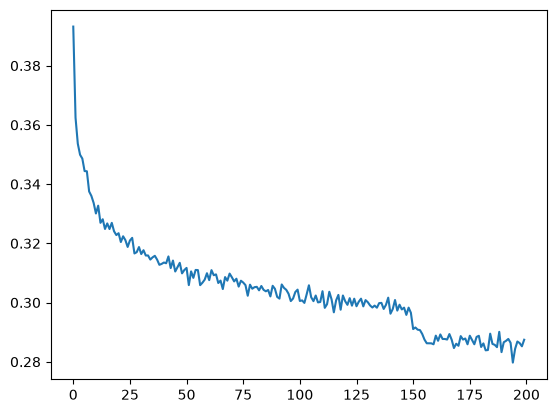

In [134]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [135]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [136]:
# evaluate the loss
@torch.no_grad()  # this decorator disables gradient tracking inside pytorch
def split_loss(split):
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.9142669439315796
val 2.0307607650756836


In [137]:
# sample from the model

for _ in range(20):

    out = []
    context = [0] * block_size  # initialize with all ...

    while True:
        # forward pass the neural net
        logits = model([torch.tensor([context])])
        probs = F.softmax(logits, dim=1)

        # sample from the distribution
        ix = torch.multinomial(probs, num_samples=1).item()

        # shift the context window and track the samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample the special '.' token, break
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))  # decode and print the generated word

zoley.
levis.
serdy.
voded.
kenleigh.
osmar.
temara.
labyre.
darius.
azil.
keilanious.
mancelse.
toprise.
kinova.
rhy.
kyan.
sena.
rayven.
lazmisa.
khalisse.


/var/folders/pk/58g3t9fj0676_6hfp0w5x1r40000gn/T/ipykernel_53631/2188379262.py:90: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:353.)
  self.out = self.weight[IX]


![Wavenet](wavenet.png)

# Why wavenet ?
In the multi layer perceptron appraoch we are squashiing down all the characters information to just a single layer 
we can ofcourse make the neural net deeper but the problem still remains that we are squashing down all the characters into a sinbgle layer
to avoid this we use the wavenet
in the wavenet image above we are not squashing all the input characters into a single layer
they are gettng squashed slowely 
in particular we are taking 2 characters and we are fusing them into some sort of a bigram representation and we do that for all of the input characters
and then we take those bigram and fuse them into a 4 character level chunks and we do this till we get a single output 
so we are going to make the network deeper and at each level we will be fusing only two consecutive elements